# Explore the LEGA-C Passive Galaxy Catalog

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.io import fits
import numpy as np

dir_catalog = "LEGAC_DR2+COSMOS15+BORGHI22.fits"

with fits.open(dir_catalog) as hdul:
    catalog = hdul[1].data
    names = hdul[1].columns.names
    print(names)

['OBJECT', 'SPECT_ID', 'RAJ2000', 'DECJ2000', 'z', 'Filename', 'SIGMA_STARS_PRIME', 'SIGMA_STARS_PRIME_err', 'SIGMA_GAS_PRIME', 'SIGMA_GAS_PRIME_err', 'LICK_CN1', 'LICK_CN1_err', 'LICK_CN2', 'LICK_CN2_err', 'LICK_CA4227', 'LICK_CA4227_err', 'LICK_G4300', 'LICK_G4300_err', 'LICK_FE4383', 'LICK_FE4383_err', 'LICK_CA4455', 'LICK_CA4455_err', 'LICK_FE4531', 'LICK_FE4531_err', 'LICK_C4668', 'LICK_C4668_err', 'LICK_HB', 'LICK_HB_err', 'LICK_HD_A', 'LICK_HD_A_err', 'LICK_HG_A', 'LICK_HG_A_err', 'LICK_HD_F', 'LICK_HD_F_err', 'LICK_HG_F', 'LICK_HG_F_err', 'LICK_D4000_N', 'LICK_D4000_N_err', 'Hd_flux', 'Hd_err', 'Hd_EW', 'Hd_EW_err', 'Hg_flux', 'Hg_err', 'Hg_EW', 'Hg_EW_err', 'Hb_flux', 'Hb_err', 'Hb_EW', 'Hb_EW_err', 'OII_3727_flux', 'OII_3727_err', 'OII_3727_EW', 'OII_3727_EW_err', 'OIII_4959_flux', 'OIII_4959_err', 'OIII_4959_EW', 'OIII_4959_EW_err', 'OIII_5007_flux', 'OIII_5007_err', 'OIII_5007_EW', 'OIII_5007_EW_err', 'f_ppxf', 'f_z', 'f_spec', 'f_primary', 'f_use', 'f_int', 'Tcor', 'SN', '

In [ ]:
mask_parent = catalog['parent'].astype(bool)
mask_photo_pass = catalog['photo_pass'].astype(bool)
mask_spectrophoto_pass = catalog['spectrophoto_pass'].astype(bool)
mask_passive = catalog['passive'].astype(bool)

masks = [mask_parent, mask_photo_pass, mask_spectrophoto_pass, mask_passive]
colors = ["#d9d9d9", "#f3a300", "#dc257e", "#400455"]
labs = ["Parent", "Photometric passive ", "Spectro-photo passive", "Bona-fide passive"]

print(f"""
Parent sample:\t\t\t{np.sum(mask_parent)}
Photometric passive sample:\t{np.sum(mask_photo_pass)}
Spectro-photo passive sample:\t{np.sum(mask_spectrophoto_pass)}
Final passive sample:\t\t{np.sum(mask_passive)}
""")


Parent sample:			1622
Photometric passive sample:	658
Spectro-photo passive sample:	485
Final passive sample:		350



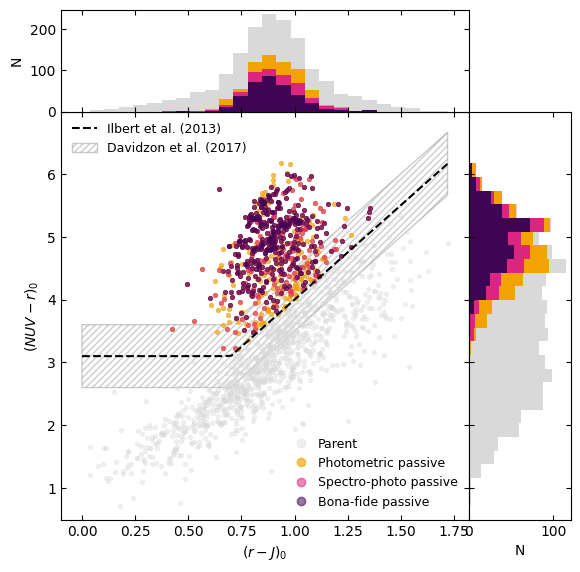

In [ ]:
# Data
NUV, R, J = catalog['M_NUV'], catalog['M_R'], catalog['M_J']
x_all, y_all = R - J, NUV - R

# Samples
masks = [mask_parent, mask_photo_pass, mask_spectrophoto_pass, mask_passive]
colors = ["#d9d9d9", "#f3a300", "#dc257e", "#400455"]
alphas = [0.4, 0.65, 0.55, 0.55]
labs = ["Parent", "Photometric passive", "Spectro-photo passive", "Bona-fide passive"]

# Figure setup
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                      left=0.13, right=0.98, bottom=0.13, top=0.98, wspace=0, hspace=0)

ax = fig.add_subplot(gs[1, 0])
ax_hx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_hy = fig.add_subplot(gs[1, 1], sharey=ax)

# Global bins (from parent sample)
x0, y0 = x_all[masks[0]], y_all[masks[0]]
bins_x = np.linspace(np.nanmin(x0), np.nanmax(x0), 26)
bins_y = np.linspace(np.nanmin(y0), np.nanmax(y0), 26)

# Plot each sample
for mask, c, a in zip(masks, colors, alphas):
    x, y = x_all[mask], y_all[mask]

    ax.scatter(x, y, s=10, c=c, ec=c, lw=0.5, alpha=a, zorder=2)
    ax_hx.hist(x, bins=bins_x, histtype='stepfilled', fc=c)
    ax_hy.hist(y, bins=bins_y, histtype='stepfilled', fc=c, orientation='horizontal')

# Ilbert+2013 selection
xi = np.linspace(0, 1.72, 50)
yi = np.where(xi > 0.7, 3*xi + 1, 3.1)
ax.plot(xi, yi, '--k', lw=1.5, label='Ilbert et al. (2013)', zorder=3)
ax.fill_between(xi, yi - 0.5, yi + 0.5, fc='white', ec='gray', hatch='/////',
                alpha=0.4, label='Davidzon et al. (2017)', zorder=1)

# Selection criteria legend (top left)
ax.legend(loc=2, framealpha=0, fontsize=9.5)

# Sample legend (bottom right)
handles = [Line2D([0], [0], marker='o', ls='', mfc=c, mec=c, ms=6, alpha=a)
           for c, a in zip(colors, alphas)]
ax.legend(handles, labs, loc=4, framealpha=0, fontsize=9, handletextpad=0.3)

# Combine both legends
leg1 = ax.legend(loc=2, framealpha=0, fontsize=9)  # re-add first legend
ax.add_artist(leg1)  # keep it when adding second
ax.legend(handles, labs, loc=4, framealpha=0, fontsize=9, handletextpad=0.3)

# Formatting
ax.set(xlim=(-0.1, 1.82), ylim=(0.5, 6.99), xlabel=r'$(r-J)_0$', ylabel=r'$(NUV-r)_0$')
for a in [ax, ax_hx, ax_hy]:
    a.tick_params(direction='in', top=True, right=True)
ax_hx.tick_params(labelbottom=False)
ax_hy.tick_params(labelleft=False)
ax_hx.set_ylabel('N')
ax_hy.set_xlabel('N')

plt.show()